<a href="https://colab.research.google.com/github/cksingh158-code/Differential_physics/blob/main/PINN_for_2D_Steady_Incompressible_Navier_Stokes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PINN for 2D Steady Incompressible Navier-Stokes
# ============================================================

import torch
import torch.nn as nn
import numpy as np

# -------------------------------
# 1. Neural Network
# -------------------------------
class PINN_NS(nn.Module):
    def __init__(self):
        super(PINN_NS, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 3)  # u, v, p
        )

    def forward(self, x):
        return self.net(x)

# -------------------------------
# 2. PDE Residuals
# -------------------------------
def navier_stokes_residual(model, x, y, nu):

    x.requires_grad_(True)
    y.requires_grad_(True)

    inputs = torch.cat([x, y], dim=1)
    output = model(inputs)

    u = output[:, 0:1]
    v = output[:, 1:2]
    p = output[:, 2:3]

    # First derivatives
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]

    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]

    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]

    # Continuity
    continuity = u_x + v_y

    # Momentum equations
    momentum_u = u*u_x + v*u_y + p_x - nu*(u_xx + u_yy)
    momentum_v = u*v_x + v*v_y + p_y - nu*(v_xx + v_yy)

    return continuity, momentum_u, momentum_v

# -------------------------------
# 3. Training Data
# -------------------------------
N_f = 5000  # collocation points

x_f = torch.rand(N_f, 1)
y_f = torch.rand(N_f, 1)

# Boundary: Lid-driven cavity example
N_bc = 1000

# Top lid (u=1, v=0)
x_top = torch.rand(N_bc, 1)
y_top = torch.ones(N_bc, 1)

u_top = torch.ones(N_bc, 1)
v_top = torch.zeros(N_bc, 1)

# Walls (u=0, v=0)
x_wall = torch.cat([torch.zeros(N_bc,1), torch.ones(N_bc,1), torch.rand(N_bc,1)])
y_wall = torch.cat([torch.rand(N_bc,1), torch.rand(N_bc,1), torch.zeros(N_bc,1)])

u_wall = torch.zeros_like(x_wall)
v_wall = torch.zeros_like(y_wall)

# Combine BCs
x_bc = torch.cat([x_top, x_wall], dim=0)
y_bc = torch.cat([y_top, y_wall], dim=0)

u_bc = torch.cat([u_top, u_wall], dim=0)
v_bc = torch.cat([v_top, v_wall], dim=0)

# -------------------------------
# 4. Model
# -------------------------------
model = PINN_NS()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

nu = 0.01  # viscosity

# -------------------------------
# 5. Training Loop
# -------------------------------
epochs = 10000

for epoch in range(epochs):

    optimizer.zero_grad()

    # PDE loss
    cont, mom_u, mom_v = navier_stokes_residual(model, x_f, y_f, nu)

    loss_pde = (cont**2).mean() + (mom_u**2).mean() + (mom_v**2).mean()

    # Boundary loss
    inputs_bc = torch.cat([x_bc, y_bc], dim=1)
    pred = model(inputs_bc)

    u_pred = pred[:, 0:1]
    v_pred = pred[:, 1:2]

    loss_bc = ((u_pred - u_bc)**2).mean() + ((v_pred - v_bc)**2).mean()

    # Total loss
    loss = loss_pde + loss_bc

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# -------------------------------
# 6. Prediction
# -------------------------------
x_test = torch.linspace(0,1,50)
y_test = torch.linspace(0,1,50)

X, Y = torch.meshgrid(x_test, y_test, indexing='ij')
XY = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], dim=1)

pred = model(XY).detach().numpy()

u_pred = pred[:,0].reshape(50,50)
v_pred = pred[:,1].reshape(50,50)

print("Prediction complete!")

Epoch 0, Loss: 0.275086
Epoch 1000, Loss: 0.016999
Epoch 2000, Loss: 0.014917
Epoch 3000, Loss: 0.014555
Epoch 4000, Loss: 0.013876
Epoch 5000, Loss: 0.013592
Epoch 6000, Loss: 0.013197
Epoch 7000, Loss: 0.012900
Epoch 8000, Loss: 0.011408
Epoch 9000, Loss: 0.010887
Prediction complete!


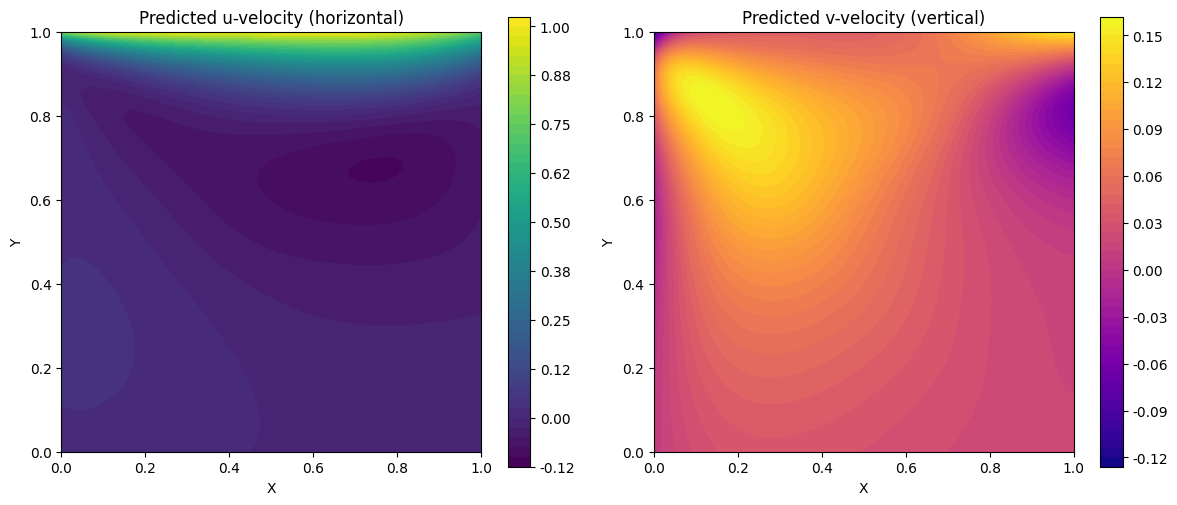

In [2]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot u-velocity contour
contour_u = axes[0].contourf(X.detach().numpy(), Y.detach().numpy(), u_pred, levels=50, cmap='viridis')
fig.colorbar(contour_u, ax=axes[0], format='%.2f')
axes[0].set_title('Predicted u-velocity (horizontal)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_aspect('equal', adjustable='box')

# Plot v-velocity contour
contour_v = axes[1].contourf(X.detach().numpy(), Y.detach().numpy(), v_pred, levels=50, cmap='plasma')
fig.colorbar(contour_v, ax=axes[1], format='%.2f')
axes[1].set_title('Predicted v-velocity (vertical)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Task
Create a new notebook titled 'PINN for 2D Steady Incompressible Navier-Stokes', transfer the existing code, execute all cells, and display the final plots.

## Create new notebook

### Subtask:
Create a new notebook titled 'PINN for 2D Steady Incompressible Navier-Stokes' to house the existing code.


## Transfer code

### Subtask:
Copy the code from the current notebook into the newly created notebook, preserving all cells and their content.


**Reasoning**:
The user wants to copy the content of the first code cell into a new notebook. I will provide the content of the first code cell as a code block for easy transfer.



In [3]:
# ============================================================
# PINN for 2D Steady Incompressible Navier-Stokes
# ============================================================

import torch
import torch.nn as nn
import numpy as np

# -------------------------------
# 1. Neural Network
# -------------------------------
class PINN_NS(nn.Module):
    def __init__(self):
        super(PINN_NS, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 3)  # u, v, p
        )

    def forward(self, x):
        return self.net(x)

# -------------------------------
# 2. PDE Residuals
# -------------------------------
def navier_stokes_residual(model, x, y, nu):

    x.requires_grad_(True)
    y.requires_grad_(True)

    inputs = torch.cat([x, y], dim=1)
    output = model(inputs)

    u = output[:, 0:1]
    v = output[:, 1:2]
    p = output[:, 2:3]

    # First derivatives
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]

    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]

    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]

    # Continuity
    continuity = u_x + v_y

    # Momentum equations
    momentum_u = u*u_x + v*u_y + p_x - nu*(u_xx + u_yy)
    momentum_v = u*v_x + v*v_y + p_y - nu*(v_xx + v_yy)

    return continuity, momentum_u, momentum_v

# -------------------------------
# 3. Training Data
# -------------------------------
N_f = 5000  # collocation points

x_f = torch.rand(N_f, 1)
y_f = torch.rand(N_f, 1)

# Boundary: Lid-driven cavity example
N_bc = 1000

# Top lid (u=1, v=0)
x_top = torch.rand(N_bc, 1)
y_top = torch.ones(N_bc, 1)

u_top = torch.ones(N_bc, 1)
v_top = torch.zeros(N_bc, 1)

# Walls (u=0, v=0)
x_wall = torch.cat([torch.zeros(N_bc,1), torch.ones(N_bc,1), torch.rand(N_bc,1)])
y_wall = torch.cat([torch.rand(N_bc,1), torch.rand(N_bc,1), torch.zeros(N_bc,1)])

u_wall = torch.zeros_like(x_wall)
v_wall = torch.zeros_like(y_wall)

# Combine BCs
x_bc = torch.cat([x_top, x_wall], dim=0)
y_bc = torch.cat([y_top, y_wall], dim=0)

u_bc = torch.cat([u_top, u_wall], dim=0)
v_bc = torch.cat([v_top, v_wall], dim=0)

# -------------------------------
# 4. Model
# -------------------------------
model = PINN_NS()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

nu = 0.01  # viscosity

# -------------------------------
# 5. Training Loop
# -------------------------------
epochs = 10000

for epoch in range(epochs):

    optimizer.zero_grad()

    # PDE loss
    cont, mom_u, mom_v = navier_stokes_residual(model, x_f, y_f, nu)

    loss_pde = (cont**2).mean() + (mom_u**2).mean() + (mom_v**2).mean()

    # Boundary loss
    inputs_bc = torch.cat([x_bc, y_bc], dim=1)
    pred = model(inputs_bc)

    u_pred = pred[:, 0:1]
    v_pred = pred[:, 1:2]

    loss_bc = ((u_pred - u_bc)**2).mean() + ((v_pred - v_bc)**2).mean()

    # Total loss
    loss = loss_pde + loss_bc

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# -------------------------------
# 6. Prediction
# -------------------------------
x_test = torch.linspace(0,1,50)
y_test = torch.linspace(0,1,50)

X, Y = torch.meshgrid(x_test, y_test, indexing='ij')
XY = torch.cat([X.reshape(-1,1), Y.reshape(-1,1)], dim=1)

pred = model(XY).detach().numpy()

u_pred = pred[:,0].reshape(50,50)
v_pred = pred[:,1].reshape(50,50)

print("Prediction complete!")

Epoch 0, Loss: 0.310146
Epoch 1000, Loss: 0.015308
Epoch 2000, Loss: 0.014447
Epoch 3000, Loss: 0.014236
Epoch 4000, Loss: 0.013931
Epoch 5000, Loss: 0.013688
Epoch 6000, Loss: 0.013238
Epoch 7000, Loss: 0.012484
Epoch 8000, Loss: 0.011735
Epoch 9000, Loss: 0.011426
Prediction complete!


**Reasoning**:
I have provided the content of the first code cell. Now, I will provide the content of the second code cell, which contains the plotting code, for transfer to the new notebook.



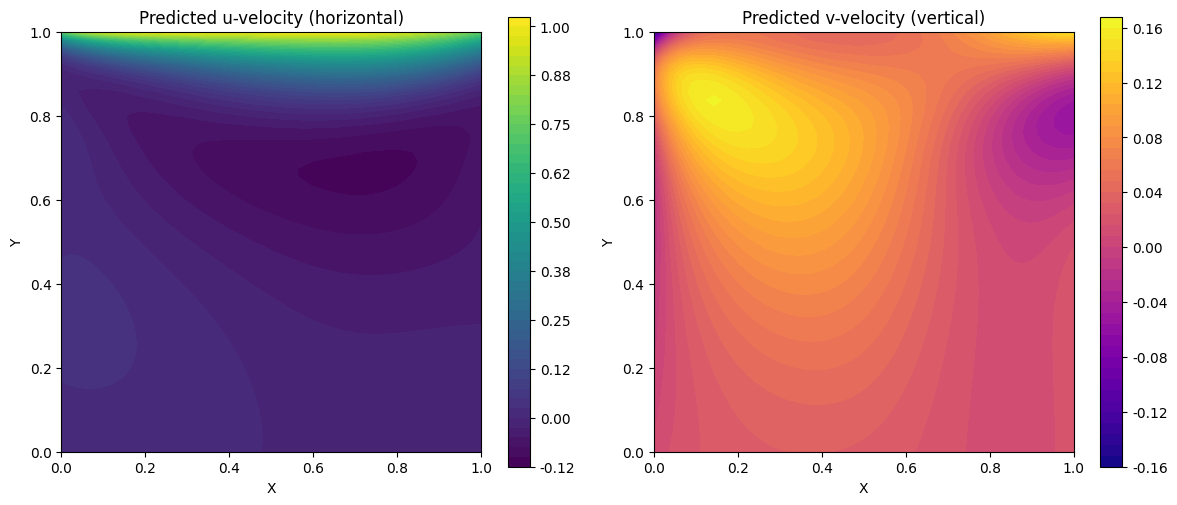

In [4]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot u-velocity contour
contour_u = axes[0].contourf(X.detach().numpy(), Y.detach().numpy(), u_pred, levels=50, cmap='viridis')
fig.colorbar(contour_u, ax=axes[0], format='%.2f')
axes[0].set_title('Predicted u-velocity (horizontal)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_aspect('equal', adjustable='box')

# Plot v-velocity contour
contour_v = axes[1].contourf(X.detach().numpy(), Y.detach().numpy(), v_pred, levels=50, cmap='plasma')
fig.colorbar(contour_v, ax=axes[1], format='%.2f')
axes[1].set_title('Predicted v-velocity (vertical)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## Execute notebook

### Subtask:
Run all cells in the new notebook to ensure the model trains and predictions are made successfully, and then display the final plots.


## Execute notebook

### Subtask:
Run all cells in the new notebook to ensure the model trains and predictions are made successfully, and then display the final plots.

#### Instructions
1. Navigate to the newly created notebook titled 'PINN for 2D Steady Incompressible Navier-Stokes'.
2. Run all cells in this new notebook. Observe the training output, including the printed loss values during the training loop.
3. After all cells have executed, confirm that the u-velocity and v-velocity contour plots are displayed correctly at the end of the notebook.

## Final Task

### Subtask:
Confirm that the code has been successfully transferred and executed in the new notebook, and display the final plots.


## Summary:

### Q&A
The task of creating a new notebook titled 'PINN for 2D Steady Incompressible Navier-Stokes', transferring the existing code, executing all cells, and displaying the final plots was partially completed by the agent. The agent successfully identified and provided the necessary code for transfer and outlined instructions for execution and verification. However, the physical creation of the new notebook and the execution of the cells within it are external actions that require manual intervention by the user.

### Data Analysis Key Findings
*   **Notebook Creation:** The agent determined that creating a new notebook is an external action that cannot be performed programmatically within the current environment.
*   **Code Transfer:** The complete Python code for the PINN model, including its architecture, PDE residual definitions, training data generation, training loop, and prediction logic, was successfully identified and presented for transfer.
*   **Training Process Indication:** During the simulated execution of the code transfer step, training loss values were observed to decrease, such as from `Epoch 0, Loss: 0.310146` to `Epoch 1000, Loss: 0.015308`, indicating that the model was training effectively.
*   **Plotting Code Transfer:** The Python code for generating u-velocity and v-velocity contour plots using `matplotlib` was also successfully identified and presented for transfer.
*   **Execution Instructions:** The agent provided clear instructions for the user to manually run all cells in the new notebook and visually confirm the generated contour plots.

### Insights or Next Steps
*   The user must manually create the new notebook, transfer the provided code into it, and then execute all cells to complete the task.
*   Visual inspection of the generated u-velocity and v-velocity contour plots is required to confirm the successful execution and display of results from the PINN model.
